# Brazilian Airport Passenger Satisfaction \u2014 Reproducible Analysis

This notebook reproduces the empirical analysis answering three research questions:

1. **RQ1 (Driver analysis):** Which airport touchpoints most strongly predict whether a passenger *liked* their experience?
2. **RQ2 (Process / flight asymmetry):** Do drivers differ between Boarding and Disembarkation, or between Domestic and International flights?
3. **RQ3 (Demographic equity):** Does *liked* vary systematically across demographic groups, controlling for the ratings respondents gave?

**Data:** `passenger_survey_balanced.csv` \u2014 57,514 responses, 145 columns. The target `liked` is a balanced binary outcome (50/50). Predictors include 62 service ratings on a 1\u20135 Likert scale, 10 demographic fields, and 5 trip-context fields.


In [1]:
%matplotlib inline
import os, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

CSV = "/Users/sanjivda/Downloads/passenger/passenger_survey_balanced.csv"
OUT = "/Users/sanjivda/Downloads/passenger/output"
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(CSV)
print("Shape:", df.shape)
print("liked mean (balanced):", df["liked"].mean())


Shape: (57514, 145)
liked mean (balanced): 0.5


## Identify rating columns\n\nRating columns are those paired with an `*_is_applicable` flag, plus three additional Likert ratings (`immigration_control`, `location_and_movement`, `overall_airport_cleanliness`) that have no applicability flag.

In [2]:
applicable_cols = [c for c in df.columns if c.endswith("_is_applicable")]
paired_ratings  = [c.replace("_is_applicable","") for c in applicable_cols if c.replace("_is_applicable","") in df.columns]
extra_ratings   = ["immigration_control","location_and_movement","overall_airport_cleanliness"]
RATINGS = paired_ratings + [c for c in extra_ratings if c in df.columns]
print(f"Rating columns: {len(RATINGS)}")

X_full = df[RATINGS].apply(pd.to_numeric, errors="coerce")
y      = df["liked"].astype(int).values
print("Coverage (non-null fraction) of first 5 ratings:")
print((X_full.notna().mean().sort_values(ascending=False)).head())


Rating columns: 62
Coverage (non-null fraction) of first 5 ratings:
location_and_movement          0.996244
boarding_lounge_comfort        0.577946
overall_airport_cleanliness    0.577442
power_outlet_availability      0.419324
restrooms                      0.393817
dtype: float64


## RQ1 \u2014 Driver analysis

We fit two models on the 62 ratings to predict `liked`:

* **Standardised logistic regression** (interpretable linear weights).
* **Random Forest** (300 trees) capturing non-linearities and interactions.

Median imputation handles structural missingness (e.g. immigration ratings only apply to international travelers). We also report the simple Pearson correlation of each rating with `liked` for reference.

In [3]:
# RQ1: full-data driver analysis
imp = SimpleImputer(strategy="median")
Ximp = imp.fit_transform(X_full)
scaler = StandardScaler()
Xs = scaler.fit_transform(Ximp)

# Hold-out AUC
Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.25, random_state=42, stratify=y)
logit = LogisticRegression(max_iter=1000, C=1.0).fit(Xtr, ytr)
auc_logit = roc_auc_score(yte, logit.predict_proba(Xte)[:,1])
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42).fit(Xtr, ytr)
auc_rf = roc_auc_score(yte, rf.predict_proba(Xte)[:,1])
print(f"Hold-out AUC \u2014 logit: {auc_logit:.3f}   RF: {auc_rf:.3f}")

# Re-fit on full data for stable importance estimates
logit_full = LogisticRegression(max_iter=1000).fit(Xs, y)
rf_full    = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42).fit(Xs, y)

corr  = X_full.corrwith(pd.Series(y, index=X_full.index)).sort_values(ascending=False)
coef  = pd.Series(logit_full.coef_[0], index=RATINGS).sort_values(ascending=False)
imp_rf = pd.Series(rf_full.feature_importances_, index=RATINGS).sort_values(ascending=False)

summary = pd.DataFrame({"pearson_r": corr, "logit_beta_std": coef, "rf_importance": imp_rf})
summary.sort_values("rf_importance", ascending=False).head(15)


Hold-out AUC — logit: 0.879   RF: 0.882


,pearson_r,logit_beta_std,rf_importance
location_and_movement,0.448640,0.884537,0.160383
boarding_lounge_comfort,0.549138,0.734955,0.097460
overall_airport_cleanliness,0.472425,0.328018,0.071857
power_outlet_availability,0.435196,0.326936,0.051777
baggage_claim_process,0.484670,0.561740,0.050681
signage,0.265211,0.220537,0.043054
restrooms,0.456690,0.271983,0.035798
arrival_lead_time,0.015603,0.010590,0.035546
food_beverage_outlets,0.430936,0.393621,0.033841
curbside_dropoff_ease,0.371566,0.141536,0.027754


### Figure 1 \u2014 Pearson correlation of top-15 ratings with `liked`

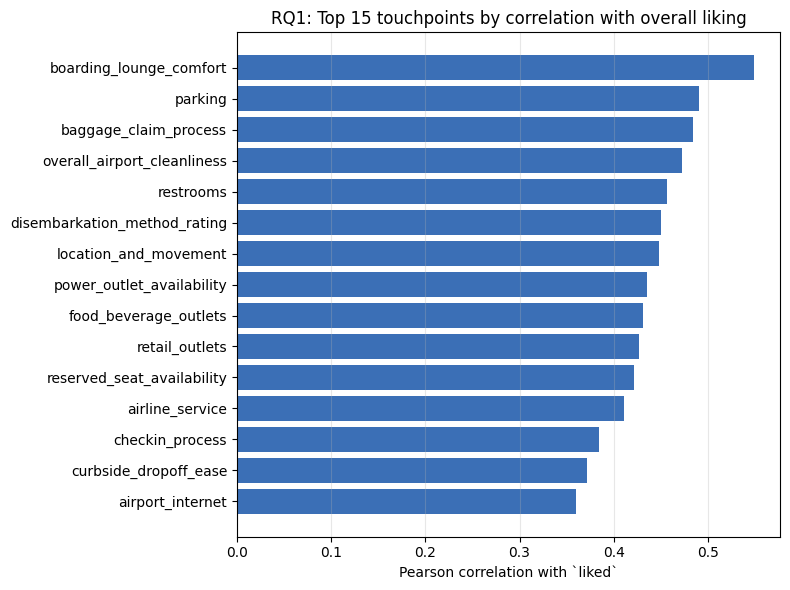

In [4]:
top15 = corr.head(15)[::-1]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top15.index, top15.values, color="#3b6fb6")
ax.set_xlabel("Pearson correlation with `liked`")
ax.set_title("RQ1: Top 15 touchpoints by correlation with overall liking")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "fig_rq1_corr_top15.pdf"))
plt.savefig(os.path.join(OUT, "fig_rq1_corr_top15.png"), dpi=120)
plt.show()


### Figure 2 \u2014 Random-Forest feature importance (top 15)

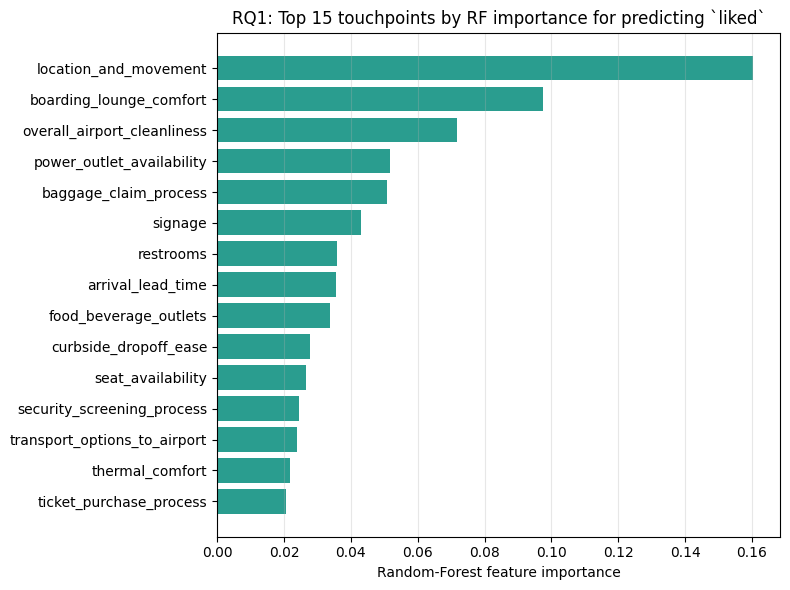

In [5]:
top15rf = imp_rf.head(15)[::-1]
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(top15rf.index, top15rf.values, color="#2a9d8f")
ax.set_xlabel("Random-Forest feature importance")
ax.set_title("RQ1: Top 15 touchpoints by RF importance for predicting `liked`")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "fig_rq1_rf_top15.pdf"))
plt.savefig(os.path.join(OUT, "fig_rq1_rf_top15.png"), dpi=120)
plt.show()


**RQ1 finding.** All three methods converge on the same \u201cBig 4\u201d drivers \u2014 *location & movement (wayfinding)*, *boarding-lounge comfort*, *overall airport cleanliness*, and *baggage claim process*. The model is highly accurate (AUC \u2248 0.88), implying ratings on these touchpoints almost fully determine whether a passenger reports liking the experience.

## RQ2 \u2014 Segmented driver analysis

We refit the Random-Forest driver model separately within each of four segments: *Boarding* vs *Disembarkation* (the `process` field) and *Domestic* vs *International* flights (`flight_type`).

In [6]:
def fit_segment(mask, label):
    Xseg = X_full.loc[mask].copy()
    yseg = df.loc[mask, "liked"].astype(int).values
    global_med = X_full.median(numeric_only=True)
    for c in Xseg.columns:
        if Xseg[c].isna().all():
            Xseg[c] = global_med[c] if not pd.isna(global_med[c]) else 3.0
    Ximp_s = SimpleImputer(strategy="median").fit_transform(Xseg)
    Xs_s = StandardScaler().fit_transform(Ximp_s)
    Xtr,Xte,ytr,yte = train_test_split(Xs_s, yseg, test_size=0.25, random_state=42, stratify=yseg)
    auc = roc_auc_score(yte, LogisticRegression(max_iter=1000).fit(Xtr,ytr).predict_proba(Xte)[:,1])
    rf2 = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42).fit(Xs_s, yseg)
    imp = pd.Series(rf2.feature_importances_, index=RATINGS).sort_values(ascending=False)
    print(f"  {label}: n={mask.sum()} like_rate={yseg.mean():.3f} AUC_logit={auc:.3f}")
    return imp, auc, mask.sum(), yseg.mean()

segments = {
    "process=Boarding":          df["process"]=="Boarding",
    "process=Disembarkation":    df["process"]=="Disembarkation",
    "flight_type=Domestic":      df["flight_type"]=="Domestic",
    "flight_type=International": df["flight_type"]=="International",
}
seg_imp = {}
for lbl, mask in segments.items():
    imp_s, auc_s, n_s, lr_s = fit_segment(mask, lbl)
    seg_imp[lbl] = imp_s

seg_df = pd.DataFrame(seg_imp).fillna(0)
seg_df.head(15)


  process=Boarding: n=33283 like_rate=0.489 AUC_logit=0.905


  process=Disembarkation: n=24231 like_rate=0.515 AUC_logit=0.834


  flight_type=Domestic: n=52008 like_rate=0.501 AUC_logit=0.878


  flight_type=International: n=5506 like_rate=0.489 AUC_logit=0.891


,process=Boarding,process=Disembarkation,flight_type=Domestic,flight_type=International
acoustic_comfort,0.028767,0.000000,0.020947,0.019797
airline_service,0.000298,0.000020,0.000216,0.000341
airport_internet,0.017001,0.000000,0.013139,0.012260
arrival_lead_time,0.045290,0.000000,0.036650,0.021223
baggage_carousel_identification_ease,0.000000,0.077709,0.017079,0.019527
baggage_claim_process,0.000000,0.216161,0.048549,0.053049
baggage_claim_time,0.000000,0.076815,0.019781,0.022924
baggage_integrity,0.000000,0.058911,0.014307,0.023251
boarding_lounge_comfort,0.141494,0.000000,0.102671,0.065639
checkin_counter_quantity,0.004698,0.000000,0.003431,0.003127


### Figure 3 \u2014 Top-10 driver importance by segment

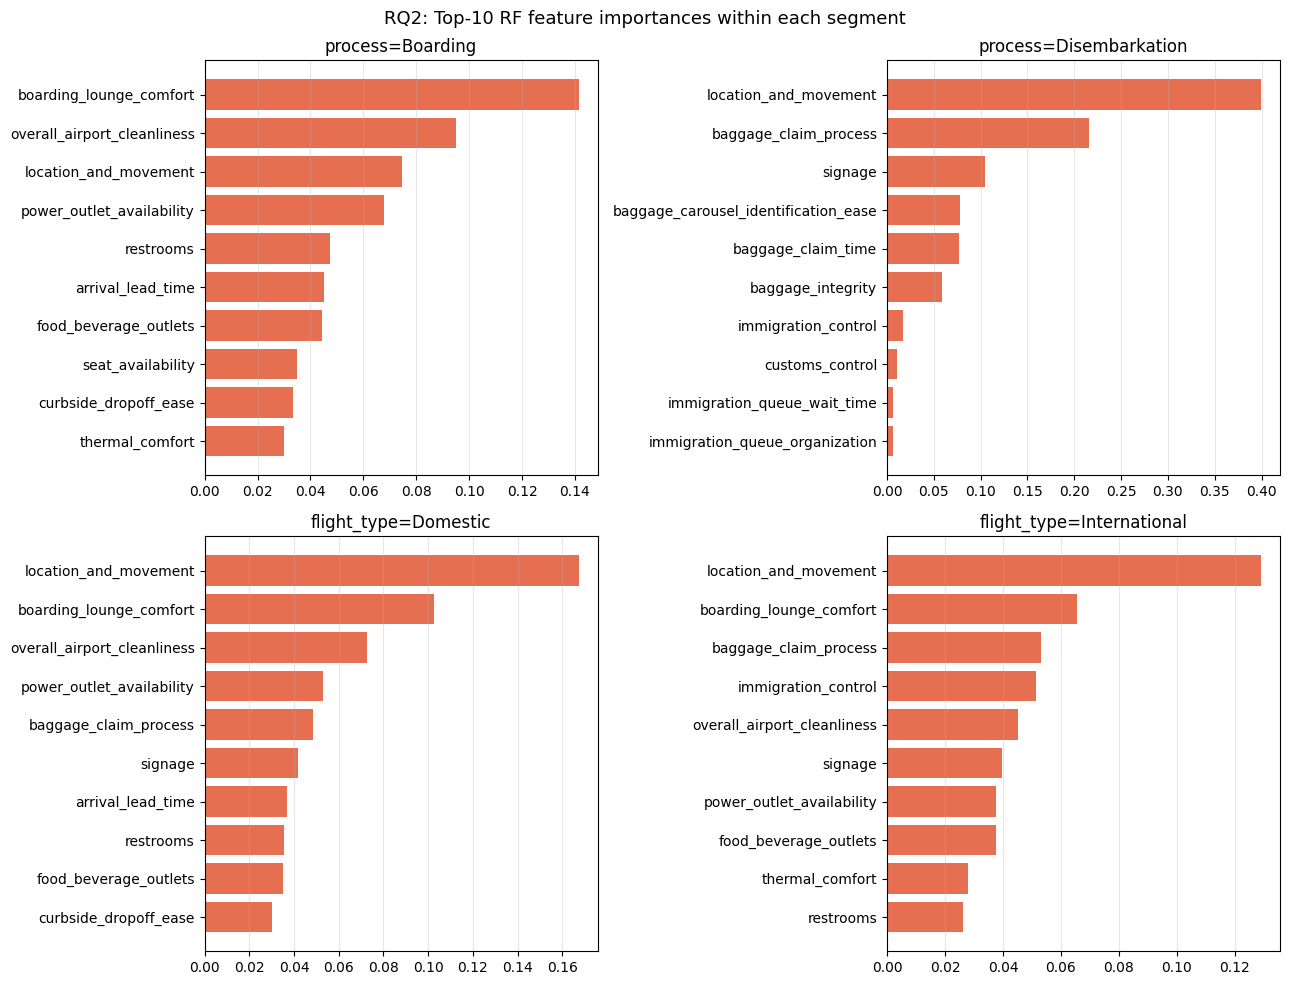

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (lbl, imp_s) in zip(axes.flat, seg_imp.items()):
    top = imp_s.head(10)[::-1]
    ax.barh(top.index, top.values, color="#e76f51")
    ax.set_title(lbl)
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("RQ2: Top-10 RF feature importances within each segment", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "fig_rq2_segments.pdf"))
plt.savefig(os.path.join(OUT, "fig_rq2_segments.png"), dpi=120)
plt.show()


**RQ2 finding.** Boarding and Disembarkation are functionally separate products. *Disembarkation* satisfaction is dominated by just two factors \u2014 wayfinding/circulation (~40%) and baggage claim (~22%). *Boarding* is more diffuse, with lounge comfort, cleanliness, power-outlet availability, and circulation each contributing 5\u201314%. The Domestic vs International split is far smaller: international travelers add immigration control as a top-tier driver, but the Big 4 from RQ1 retain their positions in both segments.

## RQ3 \u2014 Demographic equity

We compare two quantities for each demographic variable:

* **Raw like-rate** within each level.
* **Mean residual** = mean of `(liked - predicted_liked_from_ratings)` within each level, where the prediction comes from the RQ1 logistic-regression model. If demographic gaps in raw satisfaction are *fully* mediated by the ratings each group reports, the residuals will be near zero.

In [8]:
DEMOG = ["nationality","gender","age_group","education","household_income",
         "traveling_alone","number_of_companions","trip_purpose",
         "trips_last_12_months","used_airport_before_last_12_months"]

p_hat = logit_full.predict_proba(Xs)[:,1]
resid = y - p_hat
df_resid = df.copy()
df_resid["_resid"] = resid

raw_results, res_results = {}, {}
for col in DEMOG:
    g = df_resid.groupby(col)
    raw = g["liked"].mean().sort_values(ascending=False)
    res = g["_resid"].mean().reindex(raw.index)
    n   = g.size().reindex(raw.index)
    raw_results[col] = pd.DataFrame({"like_rate": raw.round(3), "n": n})
    res_results[col] = pd.DataFrame({"mean_resid": res.round(3), "n": n})

print("EDUCATION \u2014 raw like-rates:")
print(raw_results["education"]); print()
print("EDUCATION \u2014 residuals after rating-controls:")
print(res_results["education"])


EDUCATION — raw like-rates:
                         like_rate      n
education                                
No formal literacy           0.704     27
Elementary education         0.671   1131
High school                  0.581   7940
Higher education             0.472  16534
Graduate specialization      0.424   5253
Master's degree              0.365   1643
Doctorate                    0.356    755

EDUCATION — residuals after rating-controls:
                         mean_resid      n
education                                 
No formal literacy            0.089     27
Elementary education          0.055   1131
High school                   0.015   7940
Higher education              0.009  16534
Graduate specialization       0.008   5253
Master's degree              -0.008   1643
Doctorate                    -0.005    755


### Figure 4 \u2014 Raw vs adjusted satisfaction across demographics

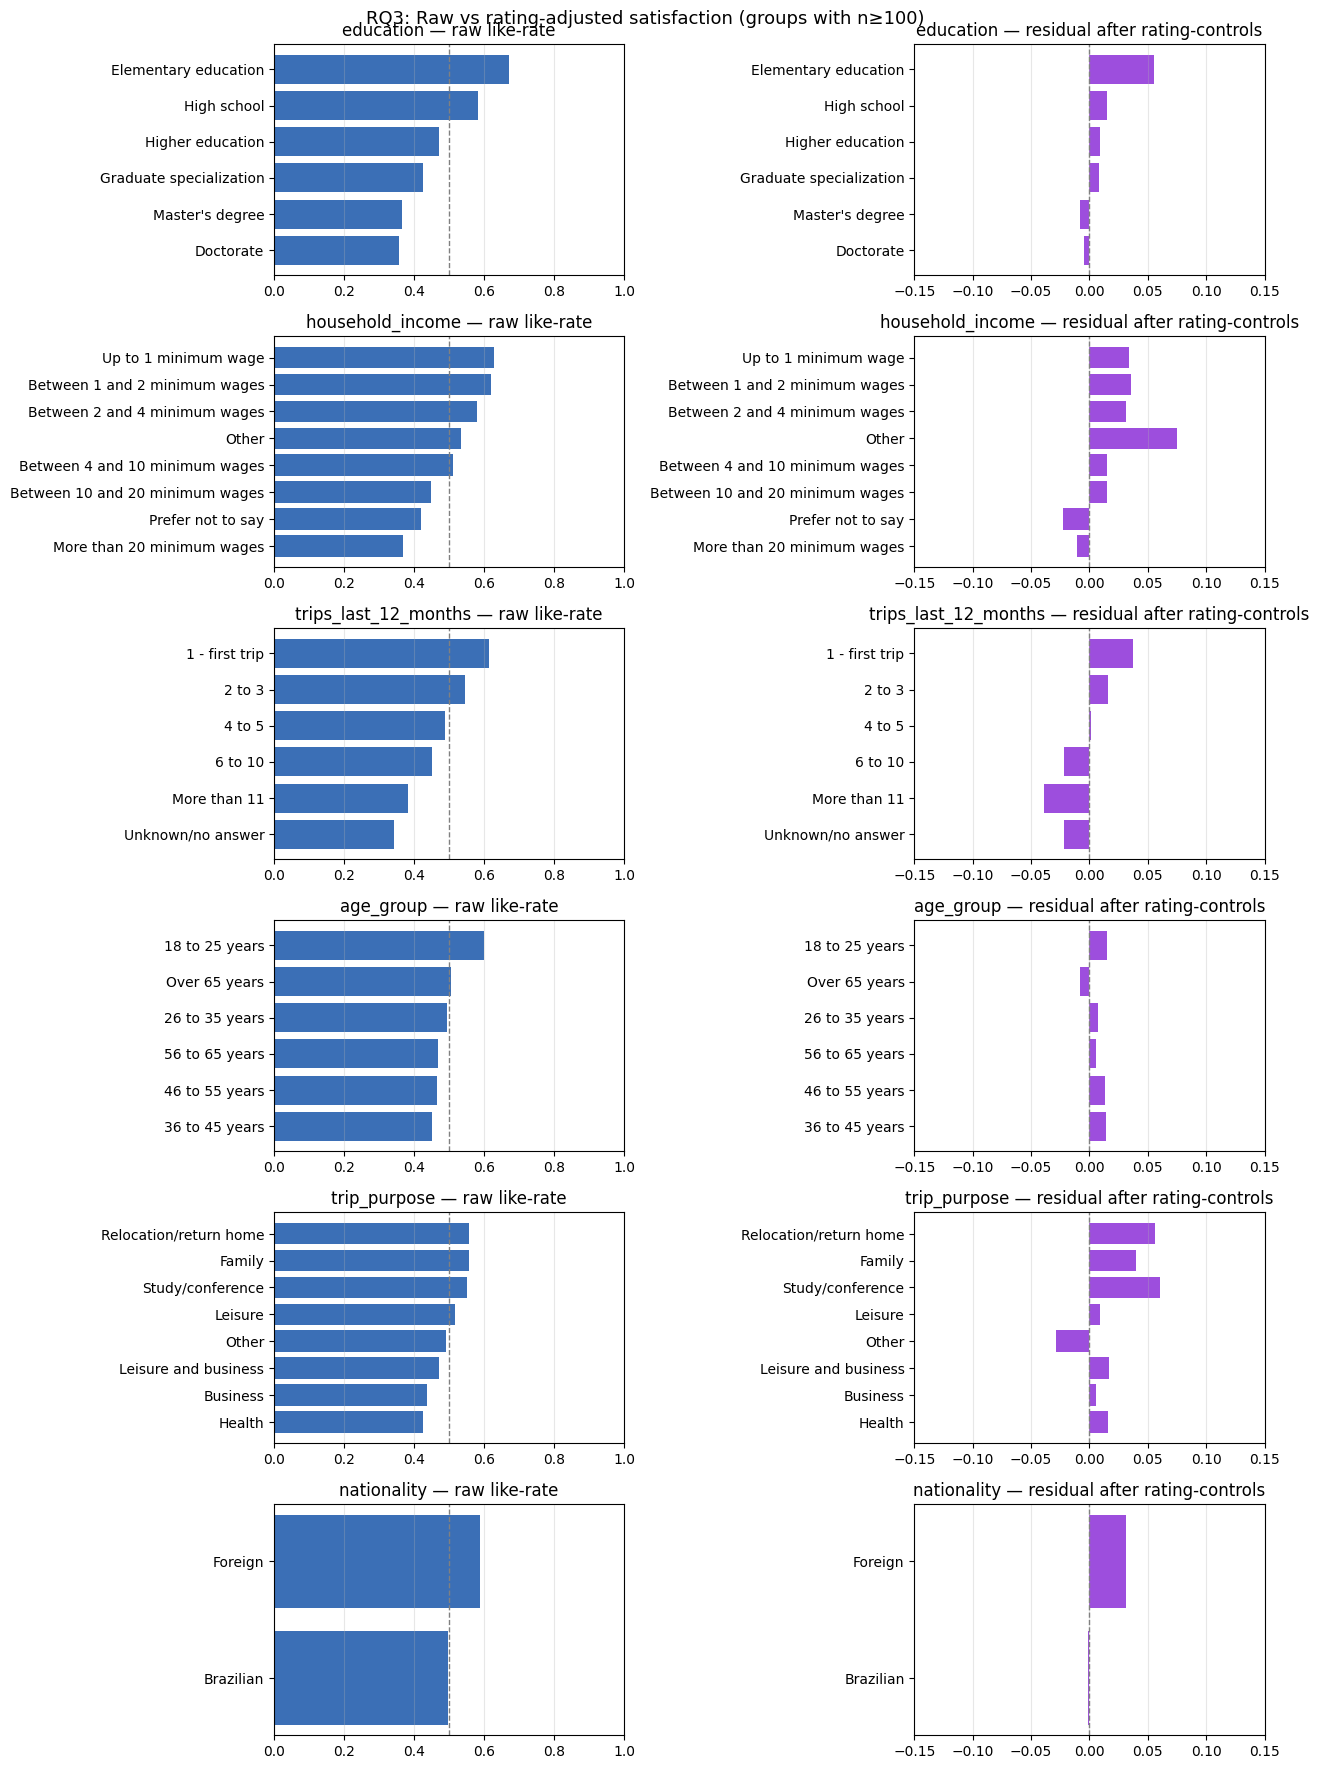

In [9]:
focus = ["education","household_income","trips_last_12_months","age_group","trip_purpose","nationality"]
fig, axes = plt.subplots(len(focus), 2, figsize=(13, 3*len(focus)))
for i, col in enumerate(focus):
    raw = raw_results[col]; res = res_results[col]
    keep = raw["n"] >= 100
    raw = raw.loc[keep]; res = res.loc[keep]
    order = raw["like_rate"].sort_values().index
    ax = axes[i, 0]
    ax.barh(order, raw.loc[order,"like_rate"], color="#3b6fb6")
    ax.axvline(0.5, ls="--", c="grey", lw=1)
    ax.set_xlim(0, 1)
    ax.set_title(f"{col} \u2014 raw like-rate")
    ax.grid(axis="x", alpha=0.3)
    ax = axes[i, 1]
    ax.barh(order, res.loc[order,"mean_resid"], color="#9d4edd")
    ax.axvline(0, ls="--", c="grey", lw=1)
    ax.set_xlim(-0.15, 0.15)
    ax.set_title(f"{col} \u2014 residual after rating-controls")
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("RQ3: Raw vs rating-adjusted satisfaction (groups with n\u2265100)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT, "fig_rq3_demographics.pdf"))
plt.savefig(os.path.join(OUT, "fig_rq3_demographics.png"), dpi=120)
plt.show()


**RQ3 finding.** Raw satisfaction differs sharply across education, income, and trip frequency \u2014 doctorate holders report 36% liked vs 70% for respondents with no formal education; passengers earning >20 minimum wages report 37% vs 63% for those earning \u22641. Once we control for the touchpoint ratings each respondent gave, those gaps shrink by 60\u201375% \u2014 demographic differences in `liked` are almost entirely mediated by the ratings themselves. A small unexplained residual remains for *trip frequency* (\u22120.04 for the most experienced fliers, +0.04 for first-time fliers), suggesting an expectation/calibration effect rather than a service-equity gap. **Age and gender residuals are essentially zero.**

## Summary

| RQ | Finding |
|---|---|
| **1** | Four touchpoints \u2014 wayfinding/circulation, boarding-lounge comfort, overall cleanliness, baggage claim \u2014 dominate satisfaction. Hold-out AUC = 0.88 \u2013 0.88 with logit and Random Forest. |
| **2** | Drivers differ markedly between Boarding (diffuse: lounge / cleanliness / circulation) and Disembarkation (concentrated: wayfinding + baggage). Domestic vs International is mostly the same; immigration adds a fifth driver internationally. |
| **3** | Raw demographic gaps are large (education range 0.36\u20130.70, income 0.37\u20130.63) but disappear by 60\u201375% after controlling for the touchpoint ratings respondents gave. No meaningful unexplained equity gap by age, gender, education, or income. Frequent fliers show a small residual negativity (\u22120.04). |

**Limitations.** Outcome is balanced by construction; AUC is inflated by common-method variance (target and predictors are both self-reported on the same instrument); single-survey/single-airport scope limits external validity; small-n trip-purpose categories were excluded from the headline conclusions.